In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

## Read the data

In [2]:
path = "../data/synthetic/test_ground_truth.json"

with open(path, "r") as f:
    data = json.load(f)

print(len(data))

1000


## Visualize the first sample

In [3]:
sample = data[0]
x_enc = sample["x_enc"]
x_dec = sample["x_dec"]
y = sample["y"]
explanation = sample["explanation"]
print(sample.keys())
print(x_enc.keys())
print(explanation.keys())

dict_keys(['x_enc', 'x_dec', 'y', 'explanation'])
dict_keys(['load', 'hourofday', 'dayofweek', 'month', 'holiday', 'temperature', 'noise1', 'noise2'])
dict_keys(['base', 'hourofday', 'dayofweek', 'month', 'holiday', 'T', 'load'])


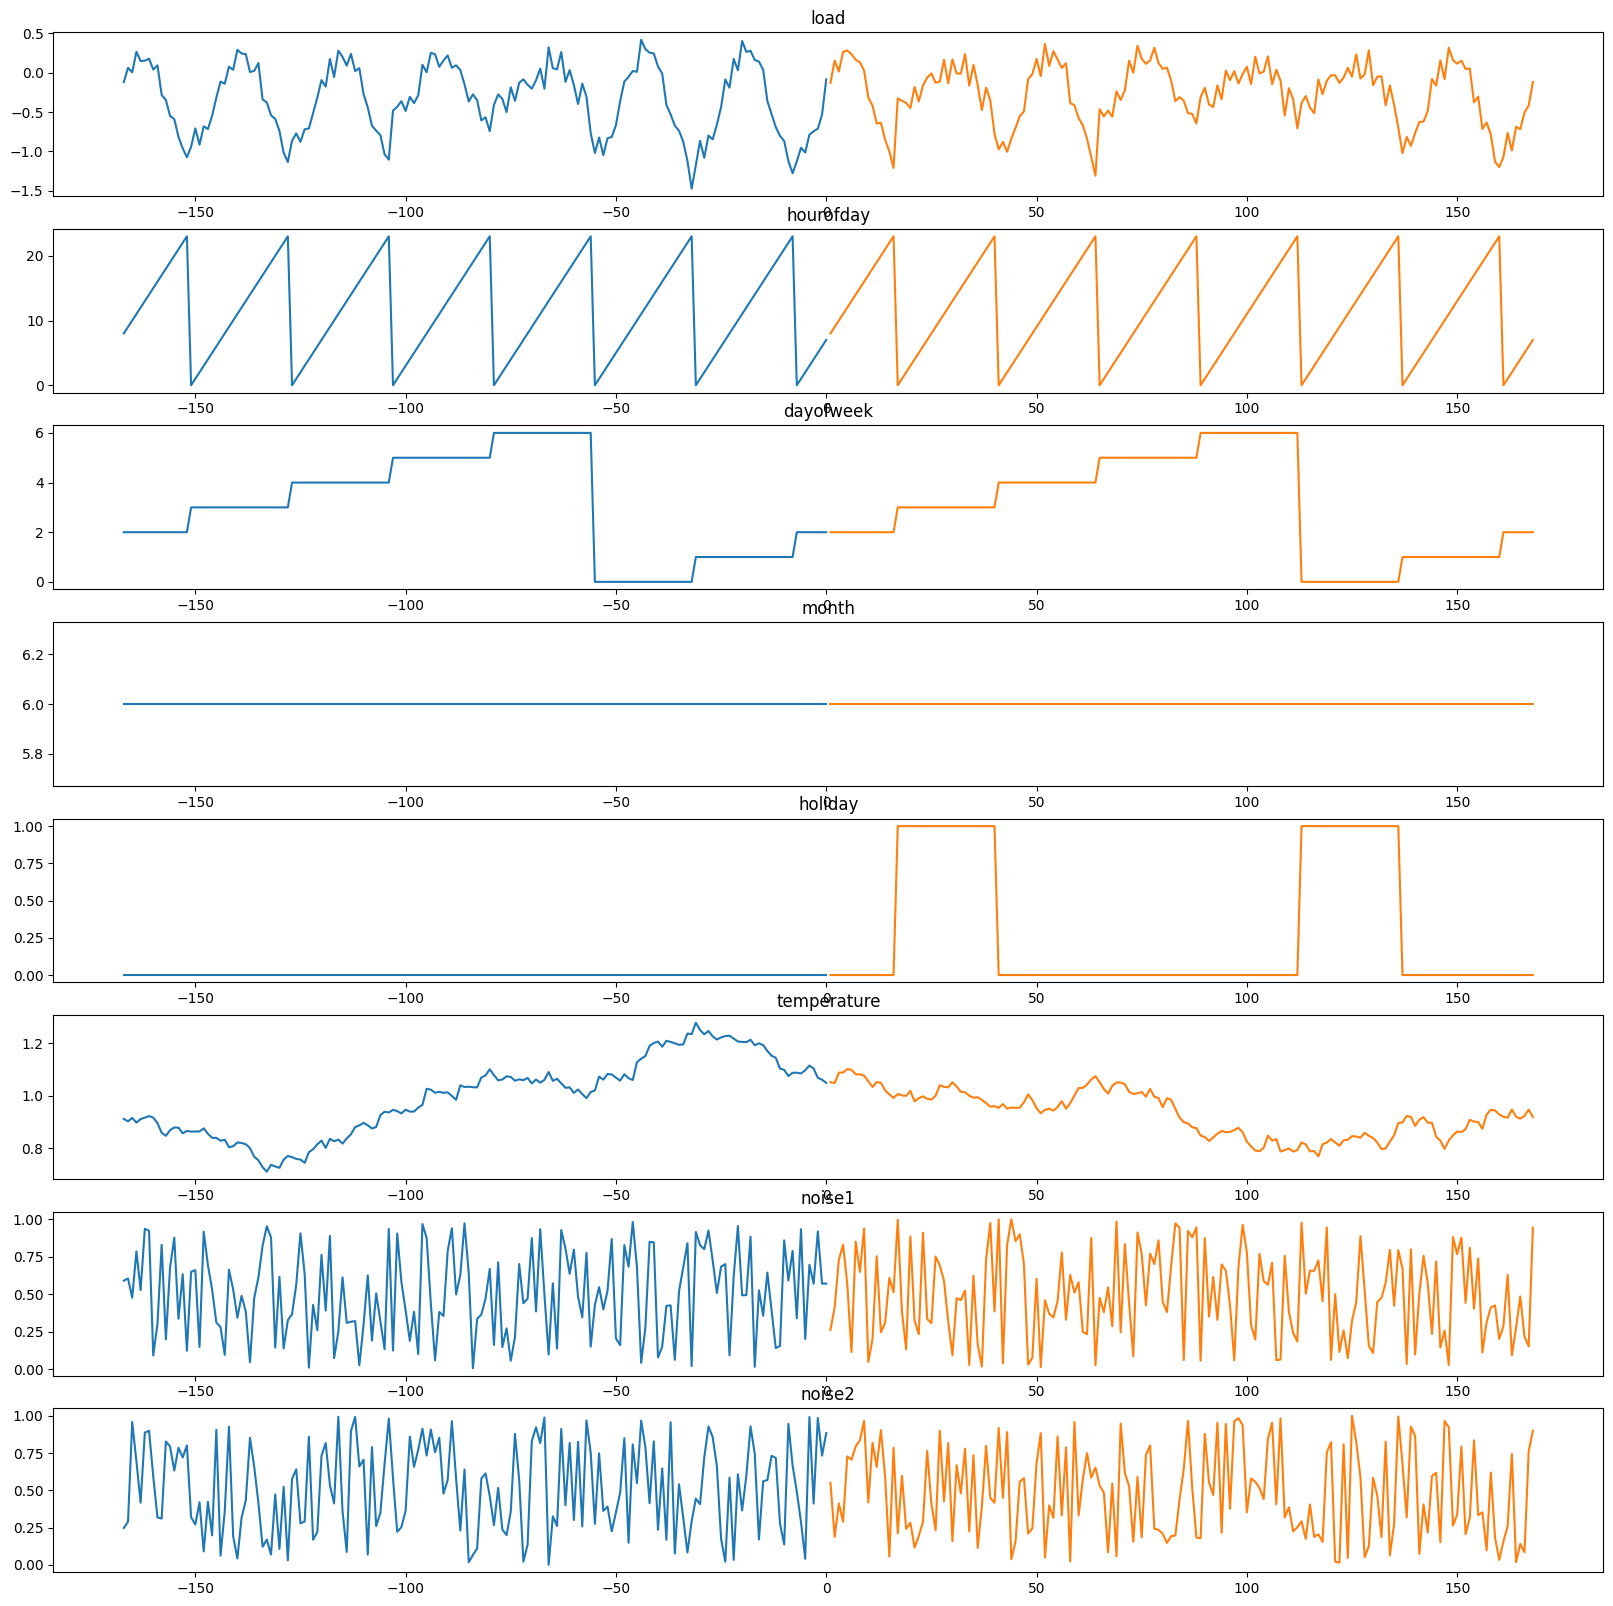

In [4]:
fig, axs = plt.subplots(len(x_enc), 1, figsize=(20, 20))

past_hours = np.arange(-167, 1)
future_hours = np.arange(1, 169)

for i, feature in enumerate(x_enc):
    axs[i].plot(past_hours, x_enc[feature])
    if feature == "load":
        axs[i].plot(future_hours, y)
    else:
        axs[i].plot(future_hours, x_dec[feature])
    axs[i].set_title(feature)

plt.show()

## Visualize the ground truth explanation

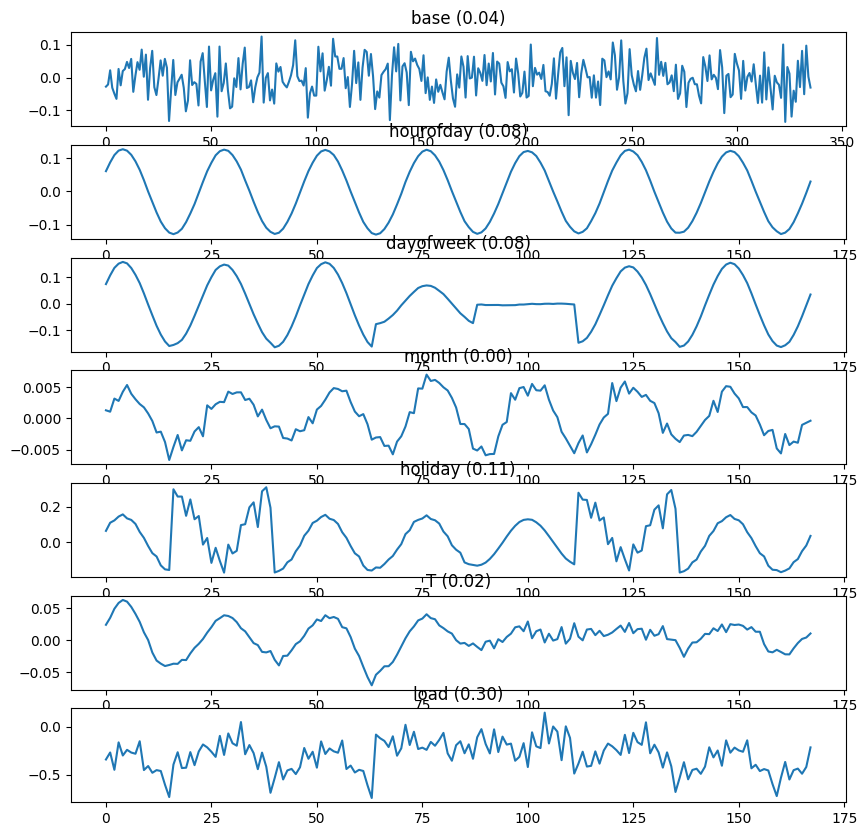

In [5]:
n_features = len(sample["explanation"])
fig, axs = plt.subplots(n_features, 1, figsize=(10, 10))
for i, feature in enumerate(sample["explanation"]):
    shap_values = sample["explanation"][feature]
    importance = np.mean(np.abs(shap_values))
    axs[i].plot(shap_values)
    axs[i].set_title(f"{feature} ({importance:.2f})")